# Machine Learning LAB 3: LINEAR REGRESSION

Course 2024/25: *F. Chiariotti*

The notebook contains some simple tasks to be performed with **LINEAR REGRESSION MODELS**.

Complete all the **required code sections**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs

## VR traffic prediction

In this notebook, we will explore the prediction of Virtual Reality (VR) traffic. The data come from the paper:

Lecci, Mattia, _et al._ "An open framework for analyzing and modeling XR network traffic." IEEE Access 9 (2021): 129782-129795.

The VR game Virus Popper was instantiated on a computer through the RiftCat application: the user could then see the virtual content on their phone, which was strapped to their head with a Cardboard viewer. The file virus_popper.csv contains three columns from the traffic capture:
idx    | frame size (B) |  time (s)
0      | 38424          |  0.0
1      | 39801          |  0.01944
...

The game was run at 60 frames per second, with a target rate of 30 Mb/s. The task is then to predict the size of the next frame, given the past N frames. This was explored in another paper:

Chiariotti, Federico, _et al._ "Temporal characterization and prediction of vr traffic: A network slicing use case." IEEE Transactions on Mobile Computing 23.5 (2023): 3890-3908.

---

## Import all the necessary Python libraries

In [41]:
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split

np.random.seed(1)

def load_dataset(filename):
    data_train = pd.read_csv(filename)
    data = data_train.iloc[:, 1].values # Get the second column (frame size) as the input
    return data

# Load the dataset
data = load_dataset('data/virus_popper.csv')

## Prepare the data and create training and test sets

In this case, we are learning a time series: let us consider a memory of 2 samples, i.e., use X[n-1] and X[n-2] to predict X[n].

In [42]:
# Normalize the dataset 
avg_size = np.mean(data)
norm_data = np.asarray(data) / avg_size

# Compute the splits and prepare the columns
m_training = int(0.75*norm_data.shape[0])

X_training = np.ones([m_training - 2, 3])
X_training[:,1] = norm_data[: m_training - 2]
X_training[:,2] = norm_data[1 : m_training - 1]
Y_training = norm_data[2 : m_training]


X_test = np.ones([norm_data.shape[0] - m_training - 2, 3])
X_test[:,1] = norm_data[m_training : -2]
X_test[:,2] = norm_data[m_training + 1 : -1]
Y_test = norm_data[m_training + 2:]

print(np.shape(X_training), np.shape(Y_training), np.shape(X_test), np.shape(Y_test))

(25878, 3) (25878,) (8625, 3) (8625,)


The CSV file contains three columns: `idx`, `frame size (B)`, and `time (s)`. However you extract only the `frame size (B)` column for further analysis. 

Then we are normalizing ensures that the frame sizes are scaled relative to their mean, improving numerical stability during modeling.

The data is prepared using a **memory window of 2 samples**, meaning:
- **Features**: The two preceding frame sizes.
- **Target**: The current frame size.

In 
```python
m_training = int(0.75*norm_data.shape[0])
X_training = np.ones([m_training - 2, 3])
X_training[:,1] = norm_data[: m_training - 2]
X_training[:,2] = norm_data[1 : m_training - 1]
Y_training = norm_data[2 : m_training]
```
- The first column of `X_training` is filled with ones (for the intercept in linear regression).
- The second and third columns contain \( X[n-1] \) and \( X[n-2] \), respectively.
- \( Y[n] \) is stored in `Y_training`.

and 

```python
X_test = np.ones([norm_data.shape[0] - m_training - 2, 3])
X_test[:,1] = norm_data[m_training : -2]
X_test[:,2] = norm_data[m_training + 1 : -1]
Y_test = norm_data[m_training + 2:]
```
- Similar to `X_training` and `Y_training`, but for the test set.

```python
print(np.shape(X_training), np.shape(Y_training), np.shape(X_test), np.shape(Y_test))
```
This line confirms that the dimensions are consistent:
- \( X \) has three columns (intercept, \( X[n-1] \), \( X[n-2] \)).
- \( Y \) has the same number of rows as \( X \).

The shapes of the datasets are printed to validate the splits and preprocessing:
1. `X_training` and `Y_training`: Training data (75% of the dataset).
2. `X_test` and `Y_test`: Test data (remaining 25%).


## Least Squares linear regression

Train and evaluate the LS regressor on the data

In [43]:
# Least squares solution
def least_squares(X_matrix: np.ndarray, labels: np.ndarray) -> None: #None perchè non sto specificando il tipo in uscita
    ## TODO: Run the LS algorithm without regularization
    # Building A matrix (external product)
    A = np.dot(X_matrix.T, X_matrix)  #Opposite of what saw in theory because there vectors where column vectors, here are rows
    # Building b vector (product between y and x)
    b = np.dot(X_matrix.T, labels)
    # Invert A and multiply by b
    w = np.linalg.inv(A).dot(b) 
    # Solving the linear system directly
    w = np.linalg.solve(A, b)  
    return w #otherwise I get a tuple (I mean, I still get a tuple, I only want its first argument)
    
def evaluate_model(x, y, coeff):
    ## TODO: Return the average MSE for the set over which we evaluate
    m = len(x)
    Emp_loss = 0
    for i in range (m):
        Emp_loss += (np.dot(coeff,x[i])-y[i])**2
    return Emp_loss/m

In [44]:
# Run the LS training and test it on the test data
trained_model = least_squares(X_training, Y_training)
mse = evaluate_model(X_test, Y_test, trained_model)
print('Model coefficients:', trained_model)
print('Training MSE:', np.sqrt(evaluate_model(X_training, Y_training, trained_model))*avg_size)
print('Root MSE:', np.sqrt(mse) * avg_size)

Model coefficients: [0.36986742 0.20348677 0.42565451]
Training MSE: 9070.165039219855
Root MSE: 7712.354721539199


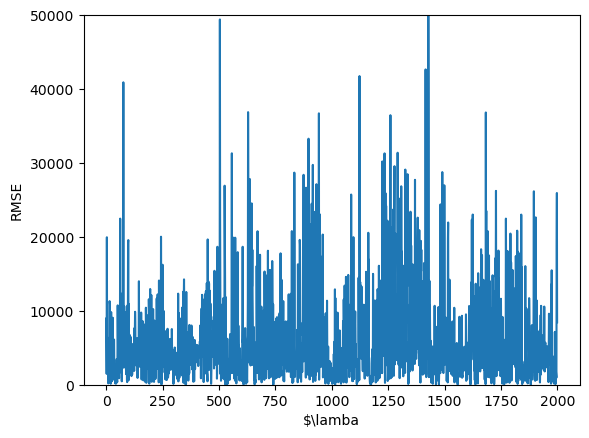

In [45]:
m = 2000
plt.plot(range(m), np.sqrt((Y_test[:m] - X_test[:m,:].dot(trained_model))**2)*avg_size)
plt.xlabel('$\lamba')
plt.ylabel('RMSE')
plt.ylim([0,50000])
plt.show()

You can then see that the fact that RMSE result is so high is due to the presence of outliers.

---

## Least Squares with Tikhonov regularization

Perform K-fold cross validation with $\lambda\in\{0, 0.1, 1, 10\}$

In [46]:
# Least squares solution
def regularized_least_squares(X_matrix: np.ndarray, labels: np.ndarray, lambda_par: np.ndarray) -> None:
    ## TODO: Run the LS algorithm with regularization
    # Building A matrix (external product)
    A = np.dot(X_matrix.T, X_matrix)  #Opposite of what saw in theory because there vectors where column vectors, here are rows
    # Building b vector (product between y and x)
    b = np.dot(X_matrix.T, labels)
    # Make the two*lambda*m*identity matrix
    add = 2*lambda_par*m*np.eye(A.shape[0])
    # Sum the two matrices
    mat = add + A
    # Invert mat and multiply by b
    w = np.linalg.inv(mat).dot(b) 
    # Solving the linear system directly
    w = np.linalg.solve(mat, b)  
    return w #otherwise I get a tuple (I mean, I still get a tuple, I only want its first argument)

def K_fold(X_training: np.ndarray, Y_training: np.ndarray, lambda_vec: np.ndarray, K: np.ndarray) -> None:
    ## TODO: Perform K-fold cross-validation
    n_samples = X_training.shape[0]
    fold_size = n_samples // K  # Number of samples per fold

    # Shuffle the dataset indices
    indices = list(range(n_samples))
    rnd.shuffle(indices)

    models = []  # Store models (weight vectors) for each lambda
    results = []  # Store average validation errors for each lambda

    for lambda_value in lambda_par:
        fold_errors = []  # Errors for each fold

        for k in range(K):
            # Determine validation and training indices for this fold
            val_start = k * fold_size
            val_end = val_start + fold_size if k != K - 1 else n_samples
            val_idx = indices[val_start:val_end]
            train_idx = [i for i in indices if i not in val_idx]

            # Split the data
            X_train, X_val = X_training[train_idx], X_training[val_idx]
            Y_train, Y_val = Y_training[train_idx], Y_training[val_idx]

            # Train using regularized least squares
            w = regularized_least_squares(X_train, Y_train, lambda_value)

            # Validate: Compute Mean Squared Error
            Y_pred = np.dot(X_val, w)  # Predict using the learned weights
            mse = np.mean((Y_pred - Y_val) ** 2)  # Mean squared error
            fold_errors.append(mse)

        # Average validation error for this lambda
        avg_error = np.mean(fold_errors)
        results.append(avg_error)
        models.append(w)

    # Find the best lambda (minimum RMSE)
    best_idx = np.argmin(results)
    best_model = models[best_idx]
    best_perf = results[best_idx]

    return best_model, best_perf, models, results


[0.37135892 0.20234695 0.42470219] [0.021428981084036583, 0.02538987116958207, 0.0346990408881936, 0.047813635078919635, 0.06346302768663574, 0.08074478491720623, 0.09901658855429343, 0.11781964443960405, 0.13682580795154717, 0.15580078927156232]


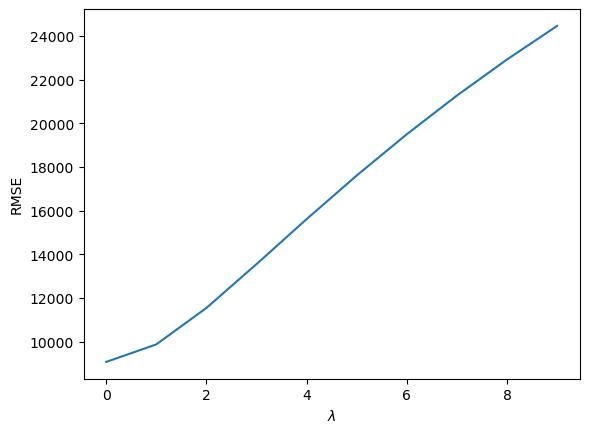

In [47]:
# Run the training with K-fold cross-validation and plot the score
K = 5
lambda_par = range(0,10)

best_model, best_perf, models, results = K_fold(X_training, Y_training, lambda_par, K)
print(best_model, results)
plt.plot(lambda_par, np.sqrt(results) * avg_size)
plt.xlabel('$\lambda$')
plt.ylabel('RMSE')
plt.show()


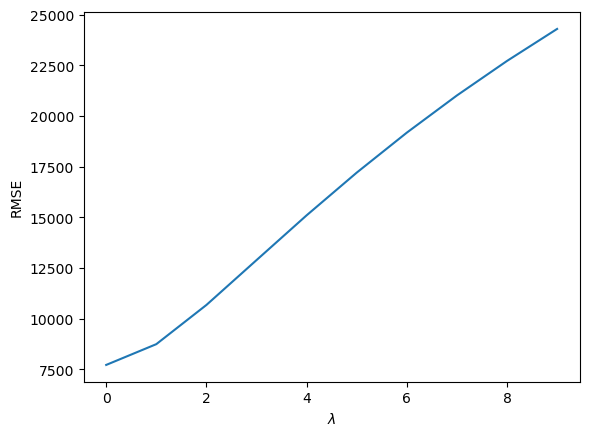

In [48]:
# Plot the results for the regularized models on the test set
test_scores = np.zeros(len(models))

for i in range(len(models)):
    test_scores[i] = evaluate_model(X_test, Y_test, models[i])

plt.plot(lambda_par, np.sqrt(test_scores) * avg_size)
plt.xlabel('$\lambda$')
plt.ylabel('RMSE')
plt.show()


What we can see from graphs, not only we have around the same difference - if you run for like lambda_par = range(101) (9 thousend - 7 thousand - actually about 8 hundred) but actually not using regularization would have been better because of outliers. 

The thing is that indipendently of regularization or not, we have not optimal solutions because of L2 loss that is really sensitive to ouliers. 

### EXTRA

Can you figure out the best amount of memory to use?

Answer in recording from min 10 more or less. 